# A · 투수별 모델

투수마다 **개별 모델**을 학습한다. 임계(4,500구) 미달 투수는 전체 모델로 폴백한다.

**핵심 질문**: 개인화가 전체 단일 모델보다 나은가? (K-fold는 모델 선택에만 쓰고, 최종 모델은 그 투수의 train 100%로 재학습)

## 설계 결정 (이번 라운드에서 이렇게 했다)

| 축 | 선택 | 이렇게 했다 |
|---|---|---|
| **A. 예측 시점** | A1 엄격 투구 전 | 예측할 투구의 **물리·위치·릴리스각·구종·결과를 전부 입력에서 제외**했다. 상황 + 그 투수/타자의 **과거**만 사용 |
| **B. fit/val 분할** | B3 경기그룹 번갈아 K-fold | `GroupKFold(game_pk)`로 **경기를 통째로** fit/val에 나눠 경기 내 인접투구 누수를 없앴다. **모델 선택에만** 쓰고 **test 2019는 고정**했다 |
| **C. 모델 구조** | C2 투수별 완전분리(+폴백) | 투수별로 개별 모델을 학습하고, `min_train=4,500` 미달 투수는 **전체 모델로 폴백**했다. K-fold로 인해 fold당 학습량이 줄어드는 문제는 **최종 모델을 train 100%로 재학습**해 해소했다 |
| **D. 모델 계열** | 로지스틱 + GBM | LogReg · HistGB · LightGBM · XGBoost를 같은 조건에서 비교했다 (TabPFN은 `05`에서 별도) |
| **E. 투수 ID 처리** | **미사용**(그룹 키로만 사용) — 투수별 모델에선 투수 ID가 상수라 피처로 넣지 않았다 | |
| **F. 튜닝** | 고정 기본값 | 이번 라운드 목적이 **계열 비교**라 하이퍼파라미터는 고정했다 (Optuna 탐색은 `01`·`02`에서 수행) |
| **G. 확률 보정** | 미적용 | isotonic/Platt는 다음 라운드 과제로 남겼다 |
| **H. 평가 프로토콜** | adaptive / prequential | 2019 진행 중 과거 2019 결과로 **이력 피처는 갱신**하되 **모델 파라미터는 2017–18에 고정**했다 |
| **I. 타깃** | 단일 `is_csw` | called_strike + swinging_strike(+blocked) |
| **J. 수축 λ** | 지표별 고정 | csw 200 · whiff 150 · called 150 · zone 200 · chase 120 · fps 100 |
| **K. 표본 범위** | 상위 40투수 | train 238,054 / **test 94,150**. 투수별 모델 임계 `min_train=4,500` |
| **L. 평가지표** | LogLoss(주) | + Brier · PR-AUC · ROC-AUC · ECE 병기 |

> ⚠️ **번갈아 K-fold의 한계**: 시간을 뒤섞으므로 fit 행의 이력피처(`_2w`/`_szn`)가 val 경기 결과를 포함할 수 있다(내삽).
> 그래서 **CV 점수는 2019 test보다 낙관적일 수 있고**, 최종 판단은 항상 **test 2019** 기준으로 했다.

### 사용 피처 — 205개 (쓸 수 있는 것 전부)
- **상황/기본**: 카운트·주자·점수차·이닝·좌우·구장·수비배치·나이·타순바퀴·휴식일·경기내 투구수·직전구종(lag)
- **투수 이력 6지표**(csw/whiff/called/zone/chase/초구스트라이크) × **7창**
  = `_day`(이번 등판) · `_2w`(14일) · `_szn`(시즌누적) · `_pszn`(지난시즌) · **`_car`(전 기간)** · **`_l100`·`_l500`(최근 N구)**
  각 창마다 **비율 + 유효분모(표본수) + 결측지시자**. 지표마다 분모가 다르다(whiff=스윙수, called=테이크수, chase=존밖수…)
- **아스널**: 구종별 평균구속(FF/SI/SL/CH)·패스트볼 구속/사용률·브레이킹 사용률 × **`_2w`·`_szn`·`_car`·`_pszn`**
- **릴리스 반복성**(Kirby 계열, command 아님): VRA/HRA 과거 SD·반복성 지수·FF 표본수·결측
- 모든 이력은 `shift(1)` 시간안전 → 현재 투구 정보 유입 없음

In [1]:
import json, sys, warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, "src"); import csw_pipeline as P
import plotstyle; plotstyle.apply()   # 한글 폰트
V2 = Path("out/v2")
meta = json.load(open("cache/meta.json"))
df = pd.read_parquet("cache/features.parquet")
tr = df["game_year"].isin(P.TRAIN_YEARS).to_numpy(); te = df["game_year"].eq(2019).to_numpy()
BASE = P.baselines(df, tr, te)
print(f"train {int(tr.sum()):,} / test {int(te.sum()):,} | 피처 {len(meta['derived_feats'])}개 | 투수 {meta['top_pitchers']}명")
print("baseline LogLoss:", {k: v["logloss"] for k, v in BASE.items()})

train 238,054 / test 94,150 | 피처 205개 | 투수 40명
baseline LogLoss: {'league_mean': 0.5957, 'count_only': 0.579, 'pitcher_te': 0.5947}


## 1. 모델 계열 비교 (투수별)
CV = 투수별 경기그룹 K-fold(모델 선택용), TEST = 각 투수 train 100% 재학습 후 2019.

In [2]:
res = {}
for f in sorted(V2.glob("per_pitcher_*.json")):
    res[f.stem.replace("per_pitcher_", "")] = json.load(open(f))
rows = {}
for m, r in res.items():
    rows[m] = {"CV_logloss": r["cv_mean"]["logloss"], "TEST_logloss": r["test_2019"]["logloss"],
               "TEST_roc_auc": r["test_2019"]["roc_auc"], "TEST_pr_auc": r["test_2019"]["pr_auc"],
               "TEST_brier": r["test_2019"]["brier"], "TEST_ece": r["test_2019"]["ece"]}
tbl = pd.DataFrame(rows).T.sort_values("TEST_logloss")
tbl["CV-TEST 격차"] = (tbl["TEST_logloss"] - tbl["CV_logloss"]).round(4)
tbl

,CV_logloss,TEST_logloss,TEST_roc_auc,TEST_pr_auc,TEST_brier,TEST_ece,CV-TEST 격차
xgb,0.5842,0.5865,0.6011,0.3596,0.1993,0.0269,0.0023
lgbm,0.6034,0.6049,0.5838,0.3431,0.2062,0.0628,0.0015


## 2. 커버리지 · 폴백
상위 40투수는 전원 임계를 넘어 폴백이 0이다. 하위 표본 투수를 포함하면 폴백 비율이 올라간다.

In [3]:
cov = {m: {"per_pitcher 적용": r["coverage_per_pitcher"], "global 폴백": r["fallback_global"],
           "적격 투수": r["n_eligible"], "임계": r["min_train"]} for m, r in res.items()}
pd.DataFrame(cov).T

,per_pitcher 적용,global 폴백,적격 투수,임계
lgbm,1.0,0.0,40.0,4500.0
xgb,1.0,0.0,40.0,4500.0


## 3. 전체 모델 대비 (동일 2019 평가집단)

In [4]:
g = {}
for f in sorted(V2.glob("global_*.json")):
    r = json.load(open(f)); g[f.stem.replace("global_","")] = r["test_2019"]["logloss"]
best_pp = tbl["TEST_logloss"].min(); best_g = min(g.values())
print(f"투수별 최고 TEST LogLoss: {best_pp:.4f} | 전체 최고: {best_g:.4f} | 차이: {best_pp-best_g:+.4f}")
print("baseline count_only:", BASE["count_only"]["logloss"], "| league_mean:", BASE["league_mean"]["logloss"])
pd.Series(g, name="global TEST logloss").to_frame()

투수별 최고 TEST LogLoss: 0.5865 | 전체 최고: 0.5760 | 차이: +0.0105
baseline count_only: 0.579 | league_mean: 0.5957


,global TEST logloss
hgb,0.5760
lgbm,0.5772
logreg,0.5789
xgb,0.5810


## 4. 결론
아래 수치 기준으로 판단한다. 투수별이 전체보다 나쁘면 **완전분리보다 부분 풀링**(전체 모델 + 투수별 보정)이 대안이다.

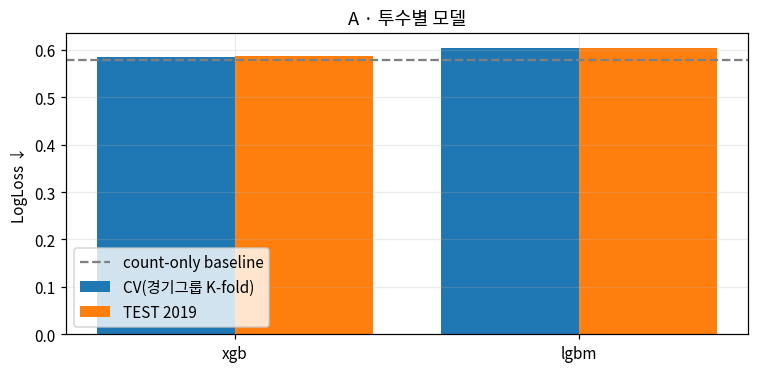

In [5]:
plt.figure(figsize=(7,3.5))
x = np.arange(len(tbl)); plt.bar(x-0.2, tbl["CV_logloss"], 0.4, label="CV(경기그룹 K-fold)")
plt.bar(x+0.2, tbl["TEST_logloss"], 0.4, label="TEST 2019")
plt.axhline(BASE["count_only"]["logloss"], ls="--", c="gray", label="count-only baseline")
plt.xticks(x, tbl.index); plt.ylabel("LogLoss ↓"); plt.title("A · 투수별 모델"); plt.legend(); plt.tight_layout(); plt.show()